In [1]:
A =    [[1,4,3],
        [2,5,1]]

B =     [[1,2],
        [1,0],
        [2,1]]

In [2]:
rows_a = len(A)
cols_a = len(A[0])
rows_b = len(B)
cols_b = len(B[0])

print(rows_a)
print(rows_b)
print(cols_a)
print(cols_b)

2
3
3
2


In [3]:
import numpy as np
c = np.zeros([0 for _ in range(cols_b) for _ in range(rows_a)])
print(c.shape)

(0, 0, 0, 0)


In [16]:
def matrix_multiplication(A,B):
        rows_a  = len(A)
        cols_a = len(A[0])
        rows_b = len(B)
        cols_b = len(B[0])

        if cols_a != rows_b:
                raise ValueError('Matrix dimensions are incompatible')
        
        c = [[0 for _ in range(cols_b)] for _ in range(rows_a)]

        for i in range(rows_a):
                for j in range(cols_b):
                        for k in range(cols_a):
                                c[i][j] += A[i][k] * B[k][j]
        return c


In [18]:
print("--- Manual Implementation ---")
manual_result = matrix_multiplication(A,B)
for row in manual_result:
        print(row)

print("\n--- NumPy Implementation ---")
numpy_result = np.dot(A, B)
print(numpy_result)

# Verification
is_equal = np.allclose(manual_result, numpy_result)
print(f"\nDo results match? {is_equal}")

--- Manual Implementation ---
[11, 5]
[9, 5]

--- NumPy Implementation ---
[[11  5]
 [ 9  5]]

Do results match? True


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# === Helper Function for styling ===
# This ensures both plots look identical in terms of grid and axes
def setup_axes(ax, limit, title):
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.axhline(y=0, color='k', linewidth=1) # Main X axis
    ax.axvline(x=0, color='k', linewidth=1) # Main Y axis
    ax.grid(True, which='both', linestyle='--')

    ax.scatter(0, 0, color='black', s=50, zorder=5) # Origin dot
    ax.set_title(title)

    # IMPORTANT: Ensure 1 unit x equals 1 unit y visually
    ax.set_aspect('equal') 

In [ ]:

# === Main Transformation Plotting Function ===
def plot_transformation_separate(matrix):
    # The unit basis vectors (rows)
    vectors = np.array([[1, 0], [0, 1]])

    # Calculate transformed vectors
    # Transpose, multiply, transpose back
    transformed_vectors = np.dot(matrix, vectors.T).T

    # Determine chart limits based on the largest vector present anywhere.
    # We want a little padding (+0.5)
    max_coord = max(np.max(np.abs(vectors)), np.max(np.abs(transformed_vectors)))
    limit = max_coord + 0.5

    # SETUP SUBPLOTS: 1 Row, 2 Columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # ====== PLOT 1: The Original Space (Left) ======
    setup_axes(ax1, limit, "Original Input Space")

    # Original i_hat (Red)
    ax1.quiver(0, 0, vectors[0, 0], vectors[0, 1],
            scale_units='xy', angles='xy', scale=1,
            color='red', label='i_hat (1,0)', zorder=3)
    
    # Original j_hat (Green)
    ax1.quiver(0, 0, vectors[1, 0], vectors[1, 1],
            scale_units='xy', scale=1, angles='xy',
            color='green', label='j_hat (0,1)', zorder=3)
    ax1.legend(loc='upper left')


    # ====== PLOT 2: The Transformed Space (Right) ======
    # Note how the title includes the matrix being applied
    setup_axes(ax2, limit, f"Transformed Output Space:\n{matrix}")

    # Transformed i_hat (Blue)
    ax2.quiver(0, 0, transformed_vectors[0, 0], transformed_vectors[0, 1],
            angles='xy', scale_units='xy', scale=1,
        color='blue', label='Transformed i_hat', zorder=3)
    
    # Transformed j_hat (Purple - changed from black for visibility against axis)
    ax2.quiver(0, 0, transformed_vectors[1, 0], transformed_vectors[1, 1],
            angles='xy', scale_units='xy', scale=1,
            color='purple', label='Transformed j_hat', zorder=3)
    ax2.legend(loc='upper left')

    plt.tight_layout() # Prevents titles from overlapping stuff
    plt.show()

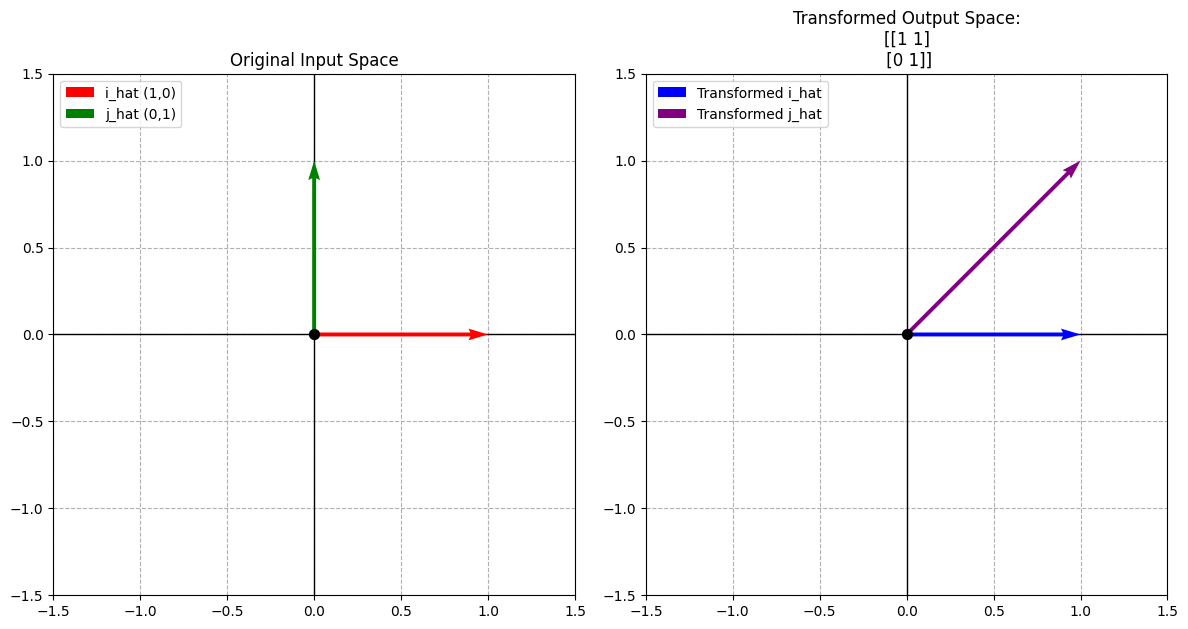

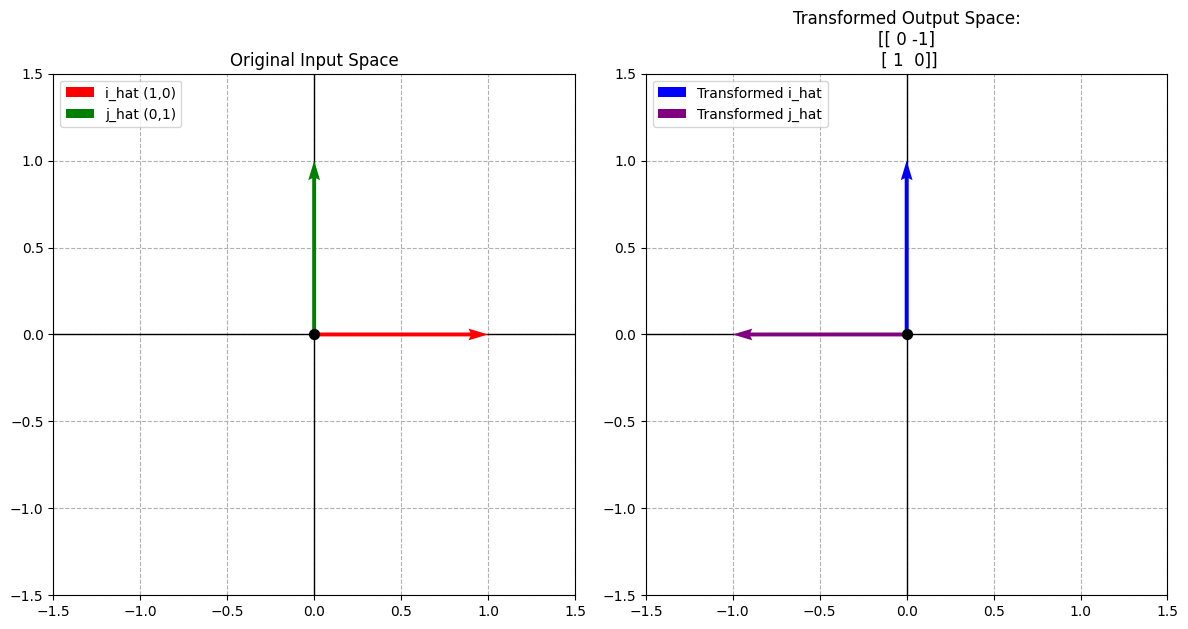

In [30]:
# Define the shear matrix
shear_matrix = np.array([
    [1, 1],
    [0, 1]
])

# Run the visualization
plot_transformation_separate(shear_matrix)

# Optional: Try a 90-degree rotation matrix to see how it looks
rotation_matrix = np.array([
    [0, -1],
    [1, 0]
])
plot_transformation_separate(rotation_matrix)